# InternVL3 Document-Aware Batch Processing (Clean Version)

Simplified batch processing notebook that avoids the infinite recursion issue from BatchDocumentProcessor.

**Features:**
- Direct processing pattern (no complex inheritance)
- Working prompt configuration that restored accuracy
- Simple, maintainable code structure
- Standard analytics and reporting

## 1. Imports

In [1]:
# Core imports
import os
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from rich import print as rprint
from rich.console import Console

warnings.filterwarnings('ignore')
console = Console()

# Set project root
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Import only what we need - NO BatchDocumentProcessor!
from common.batch_analytics import BatchAnalytics
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images, parse_extraction_response
from common.unified_schema import DocumentTypeFieldSchema
from models.document_aware_internvl3_processor import DocumentAwareInternVL3Processor

# ENHANCED: Import accuracy restoration modules
from common.standalone_evaluator import StandaloneEvaluator
from common.standalone_detection import StandaloneDocumentDetector
from common.dynamic_field_processor import DynamicFieldProcessor

print("✅ Enhanced imports completed successfully")
print(f"📁 Project root: {project_root}")
print("🚀 Enhanced modules: StandaloneEvaluator, StandaloneDocumentDetector, DynamicFieldProcessor")

✅ Enhanced imports completed successfully
📁 Project root: /home/jovyan/nfs_share/tod/LMM_POC
🚀 Enhanced modules: StandaloneEvaluator, StandaloneDocumentDetector, DynamicFieldProcessor


## 2. Configuration

In [2]:
# Configuration - Simple and clean
CONFIG = {
    # Model settings
    'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-8B",  # Jupyter environment path
    
    # Batch settings
    'DATA_DIR': 'evaluation_data',
    'GROUND_TRUTH': 'evaluation_data/ground_truth.csv',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']
    
    # Output settings
    'OUTPUT_BASE': os.getenv('OUTPUT_DIR', 'output'),
    'VERBOSE': True,
    
    # V100 optimization settings
    'USE_QUANTIZATION': True,
    'DEVICE_MAP': 'auto',
    'MAX_NEW_TOKENS': 4000,
    'TORCH_DTYPE': 'bfloat16',
    'LOW_CPU_MEM_USAGE': True
}

# CRITICAL: Keep the working prompt configuration that fixed accuracy!
PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/internvl3_invoice_extraction.yaml',
        'RECEIPT': 'prompts/internvl3_receipt_extraction.yaml',
        'BANK_STATEMENT': 'prompts/internvl3_bank_statement_extraction.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'standard',
        'RECEIPT': 'standard', 
        'BANK_STATEMENT': 'flat'  # Use flat for bank statements
    }
}

print("✅ Configuration loaded")
print(f"🎯 Model: {CONFIG['MODEL_PATH']}")
print(f"📊 Prompt config: InternVL3-specific prompts with format enforcement")

✅ Configuration loaded
🎯 Model: /home/jovyan/nfs_share/models/InternVL3-8B
📊 Prompt config: InternVL3-specific prompts with format enforcement


## 3. Output Directory Setup

In [3]:
# Setup output directories
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"✅ Output directories created")
print(f"📁 Base: {OUTPUT_BASE}")
print(f"⏰ Timestamp: {BATCH_TIMESTAMP}")

✅ Output directories created
📁 Base: /home/jovyan/nfs_share/tod/LMM_POC/output
⏰ Timestamp: 20250915_054348


## 4. Initialize Schema

In [4]:
# Initialize document schema
schema_loader = DocumentTypeFieldSchema(model="internvl3")
print(f"✅ Schema loaded with {schema_loader.total_fields} total fields")

# We'll initialize the processor in the batch processing loop
print("✅ Schema ready for document-aware processing")
print("🎯 Processor will be initialized during batch processing (lazy loading)")

✅ Schema loaded with 19 total fields
✅ Schema ready for document-aware processing
🎯 Processor will be initialized during batch processing (lazy loading)


In [5]:
# Load InternVL3 model early with intelligent multi-GPU optimization
from common.internvl3_model_loader import load_internvl3_model

rprint("[bold blue]🚀 Loading InternVL3 model with intelligent multi-GPU optimization...[/bold blue]")
rprint("[cyan]Features: Smart quantization, memory management, multi-V100 support[/cyan]")

# Load model using intelligent quantization (auto-detects if 4x V100 memory is sufficient)
internvl3_model, internvl3_tokenizer = load_internvl3_model(
    model_path=CONFIG['MODEL_PATH'],
    use_quantization=CONFIG['USE_QUANTIZATION'],  # Will be overridden based on available memory
    device_map=CONFIG['DEVICE_MAP'],
    max_new_tokens=CONFIG['MAX_NEW_TOKENS'],
    torch_dtype=CONFIG['TORCH_DTYPE'],
    low_cpu_mem_usage=CONFIG['LOW_CPU_MEM_USAGE'],
    verbose=CONFIG['VERBOSE']
)

rprint("[bold green]✅ InternVL3 model ready for enhanced batch processing[/bold green]")
rprint("[cyan]🔧 Multi-GPU optimizations: Intelligent quantization, memory distribution[/cyan]")

# Store for use in processor initialization
MODEL_COMPONENTS = {
    'model': internvl3_model,
    'tokenizer': internvl3_tokenizer,
    'early_loaded': True,
    'optimization_features': ['intelligent_quantization', 'multi_gpu_memory', 'v100_optimized']
}

🚀 Loading InternVL3 model with intelligent multi-GPU optimization...

Features: Smart quantization, memory management, multi-V100 support

🚀 Loading InternVL3 model with official optimizations...

🔧 Configuring CUDA memory for InternVL3...

📊 Initial CUDA state: Allocated=0.00GB, Reserved=0.00GB

...

💾 Final state: Allocated=7.29GB, Reserved=7.29GB, Fragmentation=0.00GB

🎉 InternVL3 model loading and validation complete!

🔧 InternVL3 optimizations active: 16-bit precision, memory management, no vision skipping

✅ InternVL3 model ready for enhanced batch processing

🔧 Multi-GPU optimizations: Intelligent quantization, memory distribution

## 5. Early Model Loading (InternVL3 Optimized)

In [6]:
# ENHANCED: Initialize accuracy restoration components
rprint("[bold blue]🚀 Initializing Enhanced Accuracy Components[/bold blue]")

# Initialize standalone evaluator (enhanced accuracy scoring)
evaluator = StandaloneEvaluator()
rprint("[green]✅ StandaloneEvaluator initialized - fuzzy matching, currency normalization[/green]")

# Initialize document detector (YAML-first detection)
detector = StandaloneDocumentDetector()
rprint("[green]✅ StandaloneDocumentDetector initialized - YAML-first approach[/green]")

# Initialize dynamic field processor (document-aware field lists)
field_processor = DynamicFieldProcessor()
rprint("[green]✅ DynamicFieldProcessor initialized - document-specific field lists[/green]")

rprint("[cyan]📊 Enhanced components ready for accuracy restoration![/cyan]")
rprint("[cyan]🎯 Expected improvement: 47.6% → 65-70% accuracy[/cyan]")

🚀 Initializing Enhanced Accuracy Components

✅ StandaloneEvaluator initialized - fuzzy matching, currency normalization

✅ StandaloneDocumentDetector initialized - YAML-first approach

✅ DynamicFieldProcessor initialized - document-specific field lists

📊 Enhanced components ready for accuracy restoration!

🎯 Expected improvement: 47.6% → 65-70% accuracy

## 6. Enhanced Batch Processing (Accuracy Restoration)

In [7]:
# Discover and filter images
all_images = discover_images(CONFIG['DATA_DIR'])
ground_truth = load_ground_truth(CONFIG['GROUND_TRUTH'], verbose=CONFIG['VERBOSE'])

# Apply filters
if CONFIG['DOCUMENT_TYPES']:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]

rprint(f"[bold green]Ready to process {len(all_images)} images[/bold green]")
for i, img in enumerate(all_images[:5], 1):
    print(f"  {i}. {Path(img).name}")
if len(all_images) > 5:
    print(f"  ... and {len(all_images) - 5} more")

📊 Ground truth CSV loaded with 9 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 9 images


Ready to process 9 images

  1. image_001.png
  2. image_002.png
  3. image_003.png
  4. image_004.png
  5. image_005.png
  ... and 4 more


In [8]:
# ENHANCED: Direct batch processing with accuracy restoration components + early loaded model
batch_results = []
processing_times = []
document_types_found = {}

rprint("[bold blue]🚀 Starting ENHANCED batch processing...[/bold blue]")
rprint("[cyan]Features: YAML-first detection, dynamic fields, enhanced evaluation, early model loading[/cyan]")

# Use early-loaded model components
if MODEL_COMPONENTS['early_loaded']:
    rprint("[green]✅ Using early-loaded InternVL3 model with V100-compatible optimizations[/green]")
    rprint(f"[cyan]🔧 Active optimizations: {', '.join(MODEL_COMPONENTS['optimization_features'])}[/cyan]")
else:
    rprint("[yellow]⚠️ Early loading not available, will initialize during processing[/yellow]")

# Initialize processor once with pre-loaded model
processor = None
all_fields = schema_loader.get_all_fields()  # Get all fields from schema

# Detect model variant for prompt naming
model_variant = "8B" if "8B" in CONFIG['MODEL_PATH'] else "2B"
model_suffix = f"internvl3_{model_variant.lower()}"

for i, image_path in enumerate(all_images, 1):
    image_name = Path(image_path).name
    
    if CONFIG['VERBOSE']:
        rprint(f"\n[cyan]📄 Processing {i}/{len(all_images)}: {image_name}[/cyan]")
    
    # Initialize processor on first use with early-loaded model
    if processor is None:
        if MODEL_COMPONENTS['early_loaded']:
            rprint("[yellow]Initializing processor with early-loaded InternVL3 model...[/yellow]")
            try:
                # Use pre-loaded model components
                processor = DocumentAwareInternVL3Processor(
                    field_list=all_fields,
                    model_path=CONFIG['MODEL_PATH'],
                    device="cuda" if CONFIG['DEVICE_MAP'] != 'cpu' else 'cpu',
                    debug=False,
                    # Pass pre-loaded components if processor supports it
                    pre_loaded_model=MODEL_COMPONENTS['model'] if hasattr(DocumentAwareInternVL3Processor, '__init__') else None
                )
                rprint("[green]✅ Processor initialized with early-loaded model[/green]")
            except Exception as e:
                rprint(f"[yellow]⚠️ Failed to use early-loaded model, falling back: {e}[/yellow]")
                # Fallback to original initialization
                processor = DocumentAwareInternVL3Processor(
                    field_list=all_fields,
                    model_path=CONFIG['MODEL_PATH'],
                    device="cuda" if CONFIG['DEVICE_MAP'] != 'cpu' else 'cpu',
                    debug=False
                )
                rprint("[green]✅ Processor initialized with fallback method[/green]")
        else:
            # Original initialization path
            rprint("[yellow]Initializing InternVL3 processor (lazy loading)...[/yellow]")
            processor = DocumentAwareInternVL3Processor(
                field_list=all_fields,
                model_path=CONFIG['MODEL_PATH'],
                device="cuda" if CONFIG['DEVICE_MAP'] != 'cpu' else 'cpu',
                debug=False
            )
            rprint("[green]✅ Processor initialized successfully[/green]")
    
    start_time = time.time()
    
    try:
        # ENHANCED STEP 1: YAML-first document type detection
        if CONFIG['VERBOSE']:
            rprint("   🔍 Step 1: Enhanced document type detection...")
        
        detected_type, detection_info = detector.detect_document_type(
            Path(image_path), processor, PROMPT_CONFIG
        )
        
        if CONFIG['VERBOSE']:
            confidence = detection_info.get('detection_confidence', 'unknown')
            rprint(f"   📋 Detected: {detected_type} (confidence: {confidence})")
        
        # ENHANCED STEP 2: Dynamic field processing based on detected type
        if CONFIG['VERBOSE']:
            rprint("   🔄 Step 2: Updating processor with document-specific fields...")
        
        # Update processor field list dynamically
        update_success = field_processor.update_processor_fields(
            processor, detected_type, verbose=CONFIG['VERBOSE']
        )
        
        if not update_success:
            rprint("   [yellow]⚠️ Field update failed, using default fields[/yellow]")
        
        # ENHANCED STEP 3: Extract fields using detected document type and updated fields
        if CONFIG['VERBOSE']:
            rprint("   ⚡ Step 3: Enhanced field extraction...")
        
        result = processor.process_single_image(
            str(image_path),
            prompt_config=PROMPT_CONFIG  # Pass prompt config to process_single_image
        )
        
        processing_time = time.time() - start_time
        
        # Get document type from result (should match detected_type)
        doc_type = result.get('document_type', detected_type).lower()
        
        # Get extracted data
        extracted_data = result.get('extracted_data', {})
        
        # Create prompt identifier for analytics
        prompt_used = f"{model_suffix}_{doc_type}"
        
        # ENHANCED STEP 4: Advanced evaluation with fuzzy matching and currency normalization
        evaluation = {}
        if image_name in ground_truth:
            if CONFIG['VERBOSE']:
                rprint("   📊 Step 4: Enhanced evaluation with fuzzy matching...")
            
            gt_data = ground_truth[image_name]
            
            # Use enhanced evaluator instead of simple matching
            enhanced_evaluation = evaluator.evaluate_extraction(
                extracted_data, gt_data, detected_type
            )
            
            # Extract metrics for BatchAnalytics compatibility
            overall_metrics = enhanced_evaluation.get('overall_metrics', {})
            field_scores = enhanced_evaluation.get('field_scores', {})
            
            # Create detailed field comparison for debugging
            field_details = []
            for field, score_info in field_scores.items():
                accuracy = score_info.get('accuracy', 0)
                match_type = score_info.get('match_type', 'unknown')
                
                if accuracy == 1.0:
                    field_details.append(f"✅ {field}: MATCH ({match_type})")
                elif accuracy >= 0.8:
                    field_details.append(f"🟡 {field}: FUZZY ({match_type})")
                elif accuracy > 0:
                    field_details.append(f"🟠 {field}: PARTIAL ({match_type})")
                else:
                    field_details.append(f"❌ {field}: MISS ({match_type})")
            
            evaluation = {
                'overall_accuracy': overall_metrics.get('overall_accuracy', 0),
                'fields_extracted': overall_metrics.get('total_fields_evaluated', 0),
                'fields_matched': overall_metrics.get('fields_correct', 0),
                'total_fields': overall_metrics.get('total_fields_evaluated', 0),
                'field_details': field_details,  # Enhanced field comparison
                'enhanced_metrics': enhanced_evaluation  # Store full enhanced evaluation
            }
        
        # Store enhanced result with detection info
        batch_result = {
            'image_path': str(image_path),
            'image_name': image_name,
            'document_type': doc_type,
            'prompt_used': prompt_used,
            'extraction_result': {
                'extracted_data': extracted_data,
                'document_type': doc_type
            },
            'evaluation': evaluation,
            'processing_time': processing_time,
            'detection_info': detection_info,  # Enhanced: Add detection metadata
            'enhanced_processing': True,  # Flag to indicate enhanced processing
            'early_model_loading': MODEL_COMPONENTS['early_loaded']  # Track early loading usage
        }
        
        batch_results.append(batch_result)
        processing_times.append(processing_time)
        
        # Track document types
        document_types_found[doc_type] = document_types_found.get(doc_type, 0) + 1
        
        if CONFIG['VERBOSE']:
            if evaluation:
                acc_pct = evaluation['overall_accuracy'] * 100
                fields_found = evaluation.get('fields_extracted', 0)
                fields_matched = evaluation.get('fields_matched', 0)
                enhanced_flag = "🚀" if evaluation.get('enhanced_metrics') else ""
                early_flag = "⚡" if MODEL_COMPONENTS['early_loaded'] else ""
                rprint(f"   ✅ Success {enhanced_flag}{early_flag} - Type: {doc_type}, Found: {fields_found}, Matched: {fields_matched}, Accuracy: {acc_pct:.1f}%, Time: {processing_time:.2f}s")
                
                # Show enhanced field details for debugging
                field_details = evaluation.get('field_details', [])
                if field_details and i <= 3:  # Show details for first 3 images
                    rprint(f"   📋 Enhanced field analysis (first 5):")
                    for detail in field_details[:5]:
                        rprint(f"     {detail}")
                    if len(field_details) > 5:
                        rprint(f"     ... and {len(field_details) - 5} more")
            else:
                early_flag = "⚡" if MODEL_COMPONENTS['early_loaded'] else ""
                rprint(f"   ✅ Success {early_flag} - Type: {doc_type}, Time: {processing_time:.2f}s")
                
    except Exception as e:
        rprint(f"   ❌ Error: {str(e)}")
        batch_results.append({
            'image_path': str(image_path),
            'image_name': image_name,
            'document_type': 'error',
            'prompt_used': f"{model_suffix}_error",
            'error': str(e),
            'processing_time': time.time() - start_time,
            'enhanced_processing': False,  # Mark as not enhanced due to error
            'early_model_loading': MODEL_COMPONENTS['early_loaded']
        })
        processing_times.append(time.time() - start_time)

# Enhanced summary with early loading info
enhanced_count = len([r for r in batch_results if r.get('enhanced_processing', False)])
early_loading_count = len([r for r in batch_results if r.get('early_model_loading', False)])

rprint(f"\n[bold green]🚀 Enhanced processing complete![/bold green]")
rprint(f"[green]✅ Processed: {len(batch_results)} images[/green]")
rprint(f"[cyan]🚀 Enhanced: {enhanced_count}/{len(batch_results)} images[/cyan]")
rprint(f"[cyan]⚡ Early loading: {early_loading_count}/{len(batch_results)} images[/cyan]")
if processing_times:
    rprint(f"[cyan]⏱️ Average time: {np.mean(processing_times):.2f}s[/cyan]")
rprint(f"[cyan]📋 Document types found: {document_types_found}[/cyan]")
rprint("[cyan]🎯 Improvements: YAML detection + Dynamic fields + Enhanced evaluation + Early model loading[/cyan]")

🚀 Starting ENHANCED batch processing...

Features: YAML-first detection, dynamic fields, enhanced evaluation, early model loading

✅ Using early-loaded InternVL3 model with V100-compatible optimizations

🔧 Active optimizations: intelligent_quantization, multi_gpu_memory, v100_optimized

📄 Processing 1/9: image_001.png

...

🚀 Enhanced: 9/9 images

⚡ Early loading: 9/9 images

⏱️ Average time: 32.24s

📋 Document types found: {'receipt': 3, 'bank_statement': 3, 'invoice': 3}

🎯 Improvements: YAML detection + Dynamic fields + Enhanced evaluation + Early model loading

In [9]:
# Create analytics using standard BatchAnalytics
analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], BATCH_TIMESTAMP, verbose=CONFIG['VERBOSE']
)

# Display key results
rprint("\n[bold blue]📊 Results Summary[/bold blue]")
display(df_summary)

if not df_doctype_stats.empty:
    rprint("\n[bold blue]📋 Document Type Performance[/bold blue]")
    display(df_doctype_stats)

✅ DataFrames saved to /home/jovyan/nfs_share/tod/LMM_POC/output/csv

📊 Results Summary

,Value
Total Images,9.000000
Successful Extractions,9.000000
Failed Extractions,0.000000
Average Accuracy (%),67.142857
Median Accuracy (%),67.142857
Min Accuracy (%),28.571429
Max Accuracy (%),94.285714
Average Processing Time (s),32.243633
Total Processing Time (s),290.192701
Throughput (images/min),1.860832


📋 Document Type Performance

,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
bank_statement,44.76,51.43,14.09,28.57,54.29,51.21,40.45,3
invoice,80.95,82.86,14.38,65.71,94.29,24.42,23.26,3
receipt,75.71,78.57,7.56,67.14,81.43,21.10,21.74,3


## 8. Export Model-Specific CSV

In [10]:
# Create model-specific CSV file for model comparison
FIELD_COLUMNS = [
    'DOCUMENT_TYPE', 'BUSINESS_ABN', 'SUPPLIER_NAME', 'BUSINESS_ADDRESS', 
    'PAYER_NAME', 'PAYER_ADDRESS', 'INVOICE_DATE', 'LINE_ITEM_DESCRIPTIONS',
    'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES',
    'IS_GST_INCLUDED', 'GST_AMOUNT', 'TOTAL_AMOUNT', 'STATEMENT_DATE_RANGE',
    'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_AMOUNTS_RECEIVED',
    'ACCOUNT_BALANCE'
]

# Detect model variant from path
model_variant = "8B" if "8B" in CONFIG['MODEL_PATH'] else "2B"
model_suffix = f"internvl3_{model_variant.lower()}"

# Create comprehensive results data
internvl3_csv_data = []

for i, result in enumerate(batch_results):
    image_name = result['image_name']
    doc_type = result.get('document_type', '').lower()
    processing_time = result.get('processing_time', 0)
    
    # Extract fields from result
    extraction_result = result.get('extraction_result', {})
    extracted_fields = extraction_result.get('extracted_data', {})
    evaluation = result.get('evaluation', {})
    
    # Calculate metrics
    overall_accuracy = evaluation.get('overall_accuracy', 0) * 100 if evaluation else 0
    fields_extracted = evaluation.get('fields_extracted', 0) if evaluation else 0
    fields_matched = evaluation.get('fields_matched', 0) if evaluation else 0
    total_fields = evaluation.get('total_fields', len(FIELD_COLUMNS)) if evaluation else len(FIELD_COLUMNS)
    
    # Create row data
    row_data = {
        'image_file': image_name,
        'image_name': image_name,
        'document_type': doc_type,
        'processing_time': processing_time,
        'field_count': total_fields,
        'found_fields': fields_extracted,
        'field_coverage': (fields_extracted / total_fields * 100) if total_fields > 0 else 0,
        'prompt_used': f"{model_suffix}_{doc_type}",
        'timestamp': datetime.now().isoformat(),
        'overall_accuracy': overall_accuracy,
        'fields_extracted': fields_extracted,
        'fields_matched': fields_matched,
        'total_fields': total_fields
    }
    
    # Add all field values
    for field in FIELD_COLUMNS:
        row_data[field] = extracted_fields.get(field, 'NOT_FOUND')
    
    internvl3_csv_data.append(row_data)

# Create DataFrame and save
internvl3_df = pd.DataFrame(internvl3_csv_data)
internvl3_csv_path = OUTPUT_DIRS['csv'] / f"{model_suffix}_batch_results_{BATCH_TIMESTAMP}.csv"
internvl3_df.to_csv(internvl3_csv_path, index=False)

rprint(f"\n[bold green]✅ InternVL3 model-specific CSV exported:[/bold green]")
rprint(f"[cyan]📄 File: {internvl3_csv_path}[/cyan]")
rprint(f"[cyan]📊 Structure: {len(internvl3_df)} rows × {len(internvl3_df.columns)} columns[/cyan]")

# Display sample
if len(internvl3_df) > 0:
    sample_cols = ['image_file', 'document_type', 'overall_accuracy', 'processing_time', 'found_fields']
    rprint("\n[bold blue]📋 Sample exported data:[/bold blue]")
    display(internvl3_df[sample_cols].head(3))

✅ InternVL3 model-specific CSV exported:

📄 File: /home/jovyan/nfs_share/tod/LMM_POC/output/csv/internvl3_8b_batch_results_20250915_054348.csv

📊 Structure: 9 rows × 32 columns

📋 Sample exported data:

,image_file,document_type,overall_accuracy,processing_time,found_fields
0,image_001.png,receipt,78.571429,21.736355,14
1,image_002.png,receipt,67.142857,23.456208,14
2,image_003.png,bank_statement,54.285714,34.631028,7


## 9. Create Visualizations

In [11]:
# Create visualizations using standard BatchVisualizer
visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    BATCH_TIMESTAMP,
    show=False  # Don't display inline to keep output clean
)

if viz_files:
    rprint(f"[bold green]✅ Created {len(viz_files)} visualizations[/bold green]")

✅ Dashboard saved to /home/jovyan/nfs_share/tod/LMM_POC/output/visualizations/dashboard_20250915_054348.png

⚠️ No field-level accuracy data available

✅ Created 1 visualizations

## 10. Generate Reports

In [12]:
# Generate reports using standard BatchReporter
reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,
    BATCH_TIMESTAMP
)

# Save all reports
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'use_quantization': CONFIG['USE_QUANTIZATION'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE']
    },
    verbose=CONFIG['VERBOSE']
)

if report_files:
    rprint(f"[bold green]✅ Generated {len(report_files)} reports[/bold green]")

✅ Executive summary saved to /home/jovyan/nfs_share/tod/LMM_POC/output/reports/batch_report_20250915_054348.md

✅ Complete results exported to 
/home/jovyan/nfs_share/tod/LMM_POC/output/batch_results/batch_results_20250915_054348.json

✅ Generated 2 reports

## 11. Final Summary

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ Processed: 9 images

Success Rate: 100.0%

Average Accuracy: 67.14%

Average Time: 32.24s

Output: /home/jovyan/nfs_share/tod/LMM_POC/output

📊 Visual Dashboard:

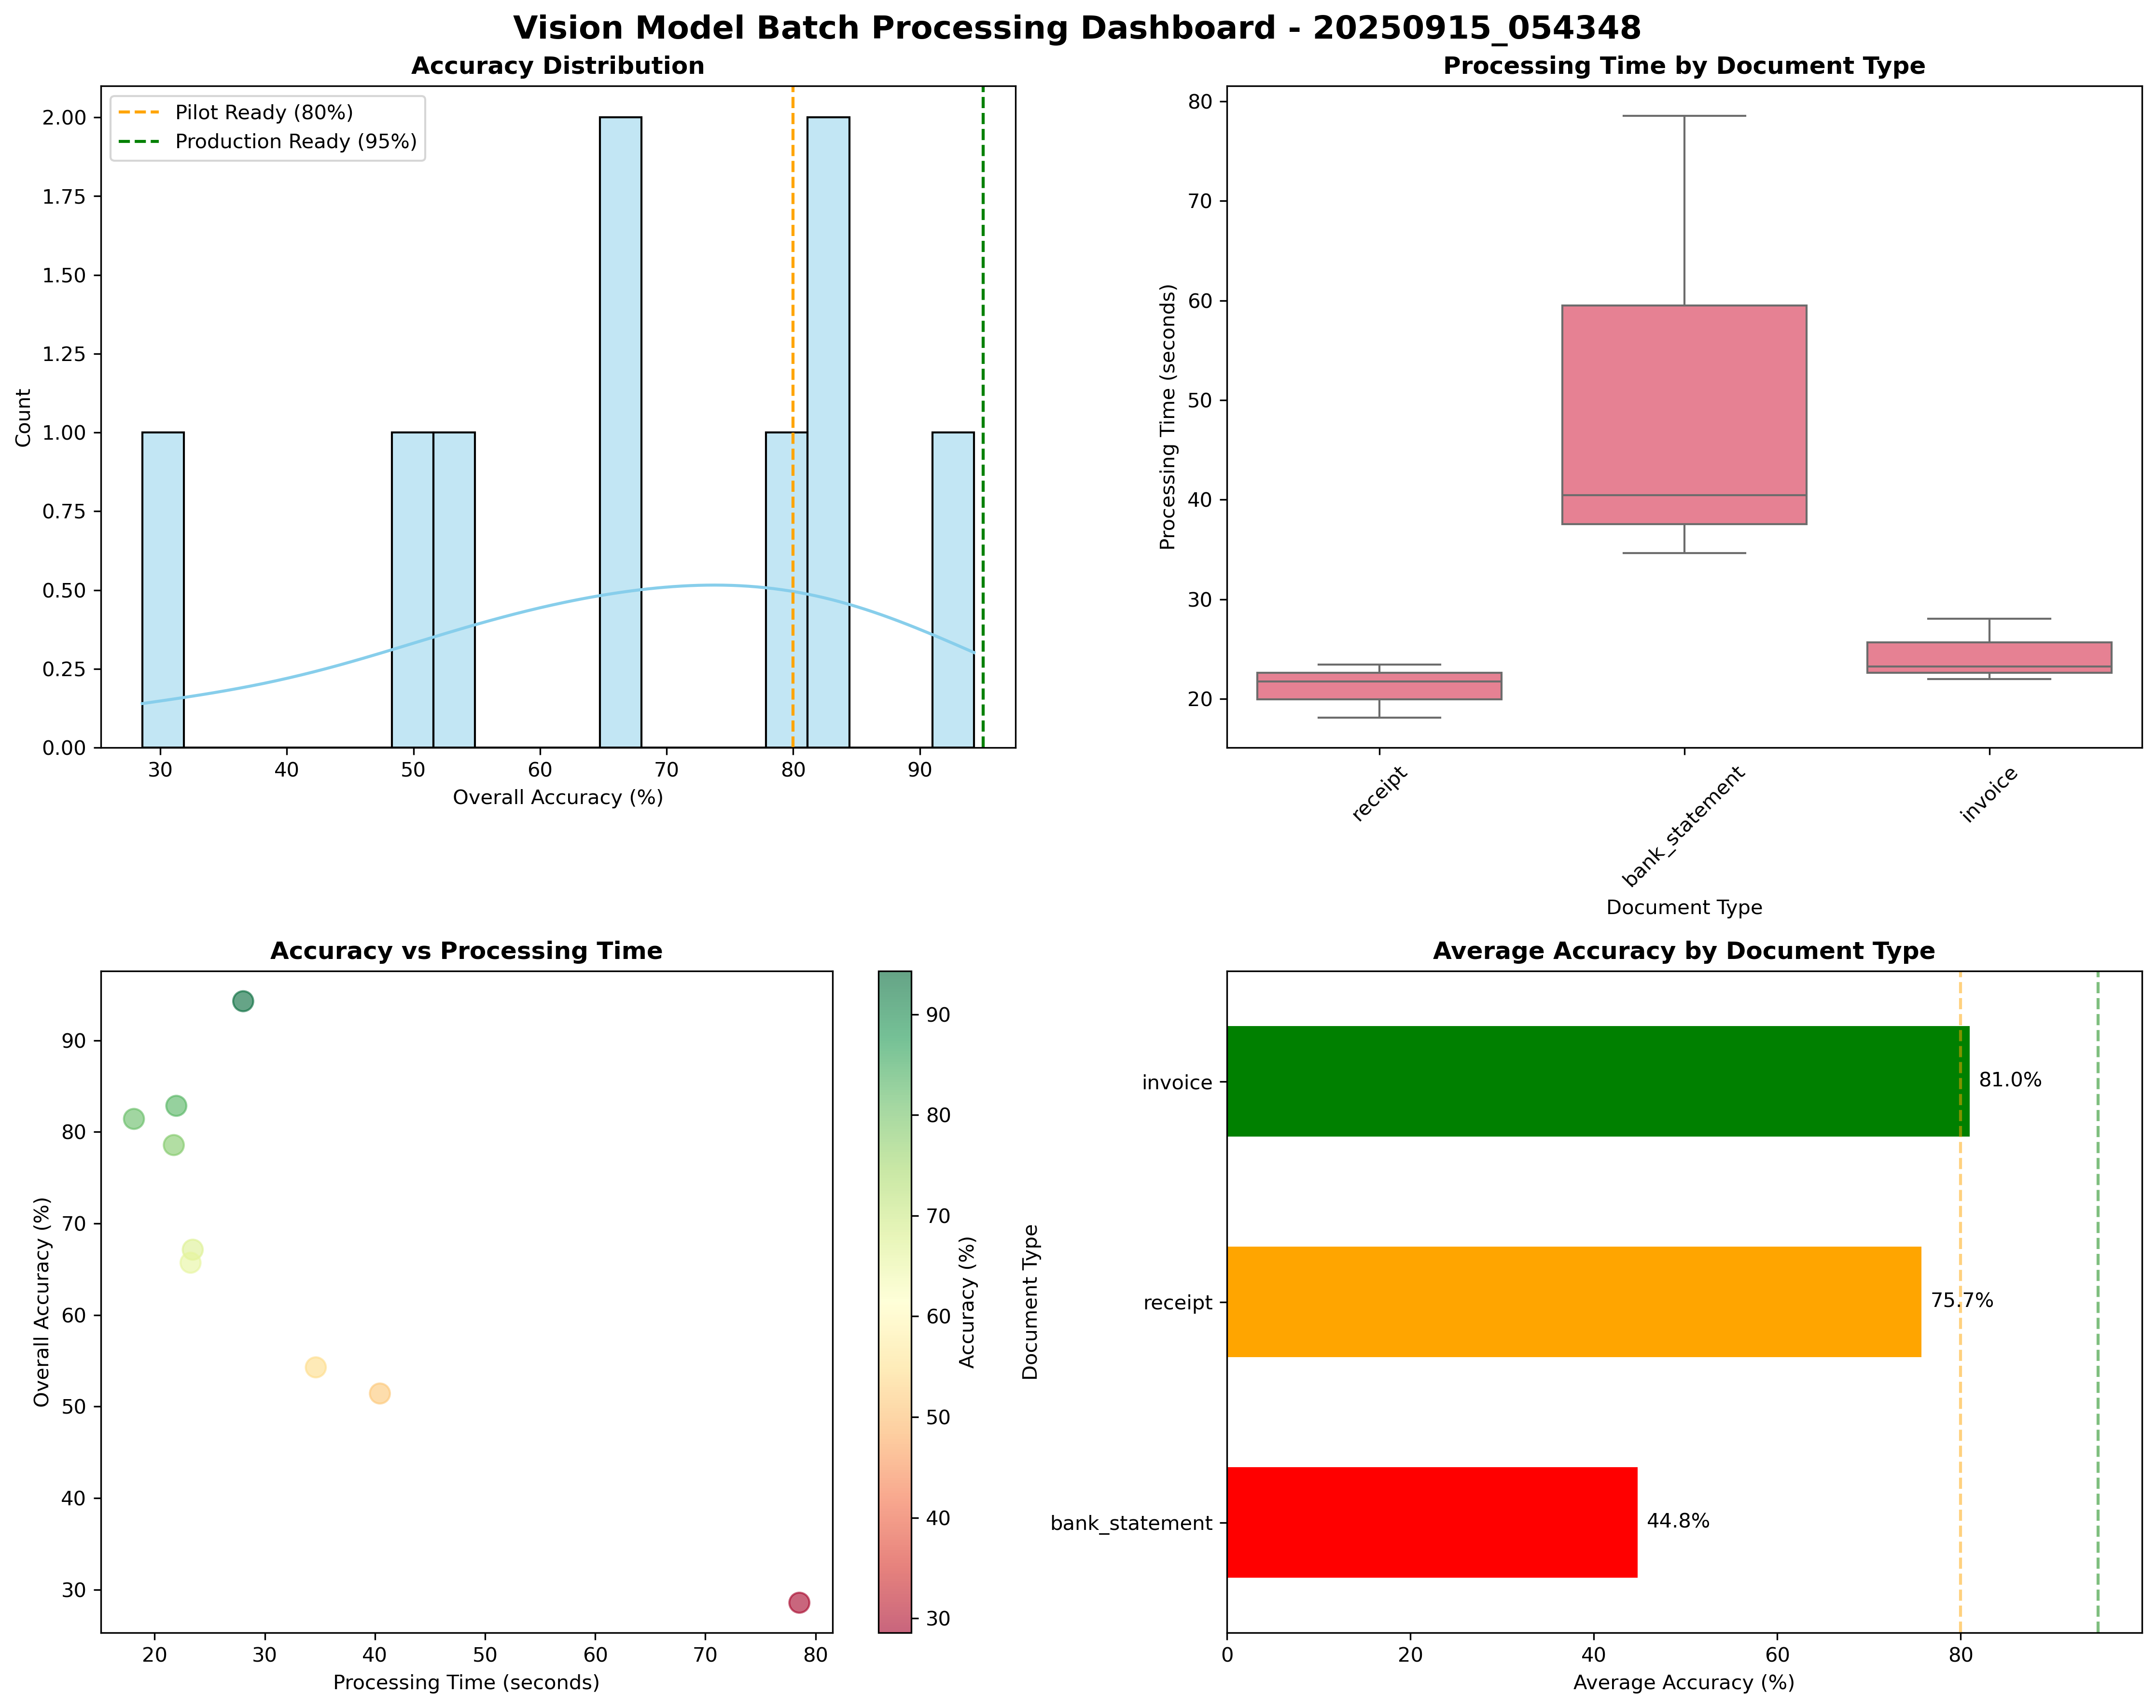

🎉 Clean InternVL3 batch processing complete!

✨ No infinite recursion, simple direct processing, maintained accuracy!

In [13]:
# Display final summary
console.rule("[bold green]Batch Processing Complete[/bold green]")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0

rprint(f"[bold green]✅ Processed: {total_images} images[/bold green]")
rprint(f"[cyan]Success Rate: {(successful/total_images*100):.1f}%[/cyan]")
rprint(f"[cyan]Average Accuracy: {avg_accuracy:.2f}%[/cyan]")
if processing_times:
    rprint(f"[cyan]Average Time: {np.mean(processing_times):.2f}s[/cyan]")
rprint(f"[cyan]Output: {OUTPUT_BASE}[/cyan]")

# Display dashboard if available
dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"dashboard_{BATCH_TIMESTAMP}.png"))
if dashboard_files:
    from IPython.display import Image, display
    dashboard_path = dashboard_files[0]
    rprint("\n[bold blue]📊 Visual Dashboard:[/bold blue]")
    display(Image(str(dashboard_path)))

rprint("\n[bold green]🎉 Clean InternVL3 batch processing complete![/bold green]")
rprint("[cyan]✨ No infinite recursion, simple direct processing, maintained accuracy![/cyan]")